In [1]:
from torch.utils.data import DataLoader
from datasets import load_dataset
from torchvision import transforms
import torch
from transformers import AutoImageProcessor

# 각각의 데이터 경로에서 데이터셋 로드
dataset = load_dataset("imagefolder", data_dir="/workspace/dataset/crop")

# 'facebook/deit-base-patch16-224' 모델에 맞는 processor 로드
processor = AutoImageProcessor.from_pretrained('google/vit-base-patch16-224-in21k')

# 전처리 함수 정의 (증강 없이)
def preprocess_images_without_augmentation(examples):
    images = examples['image']
    processed_images = []

    for img in images:
        if img.mode != 'RGB':
            img = img.convert('RGB')
        if img.size != (224, 224):  # 크기가 다른 경우만 조정
            img = img.resize((224, 224))
            
        processed_images.append(img)

    inputs = processor(images=processed_images, return_tensors="pt", size=(224,224))
    inputs['label'] = examples['label']
    return inputs



test_dataset = dataset['test'].map(preprocess_images_without_augmentation, batched=True)


/root/miniconda3/envs/kms/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2024-12-24 05:20:36.643553: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1735017636.674887   12654 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1735017636.684499   12654 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To us

In [3]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from transformers import Trainer, TrainingArguments, ViTForImageClassification
from sklearn.metrics import accuracy_score

# 모델 저장 경로
output_model_dir = "/workspace/kms/models/vit-8444"

# 2. 저장된 모델 불러오기
model = ViTForImageClassification.from_pretrained(output_model_dir)

# 3. 평가를 위한 Trainer 설정
training_args = TrainingArguments(
    output_dir="./results",  # 결과 저장 폴더
    per_device_eval_batch_size=32,  # 배치 크기
    do_eval=True,  # 평가 활성화
)

# 평가를 위한 metrics 함수 정의 (정확도 계산)
def compute_metrics(p):
    predictions, labels = p
    preds = predictions.argmax(axis=1)  # 예측값을 확률 값에서 가장 큰 인덱스로 변환
    accuracy = accuracy_score(labels, preds)  # 정확도 계산
    return {"accuracy": accuracy}

# Trainer 객체 생성
trainer = Trainer(
    model=model,  # 학습된 모델
    args=training_args,  # TrainingArguments 객체
    compute_metrics=compute_metrics,  # metrics 함수
    eval_dataset=test_dataset  # 테스트 데이터셋
)

# 4. 모델 평가
eval_results = trainer.evaluate()

# 5. 정확도 출력
print("Evaluation Results:", eval_results)


Evaluation Results: {'eval_loss': 0.4940887689590454, 'eval_model_preparation_time': 0.0048, 'eval_accuracy': 0.8444444444444444, 'eval_runtime': 155.062, 'eval_samples_per_second': 7.545, 'eval_steps_per_second': 0.239}


In [12]:
from torch.utils.data import DataLoader

test_dataset.set_format(type="torch", columns=["pixel_values", "label"])

# collate_fn으로 배치 전처리
def collate_fn(batch):
    pixel_values = torch.stack([item['pixel_values'] for item in batch])
    labels = torch.tensor([item['label'] for item in batch])
    return {'pixel_values': pixel_values, 'label': labels}

# DataLoader 생성
test_loader = DataLoader(test_dataset, batch_size=32, collate_fn=collate_fn, shuffle=False)


In [13]:
for example in test_loader:
    print(example['pixel_values'].shape)  # 이미지 크기 확인
    break  # 첫 번째 샘플만 확인


torch.Size([32, 3, 224, 224])


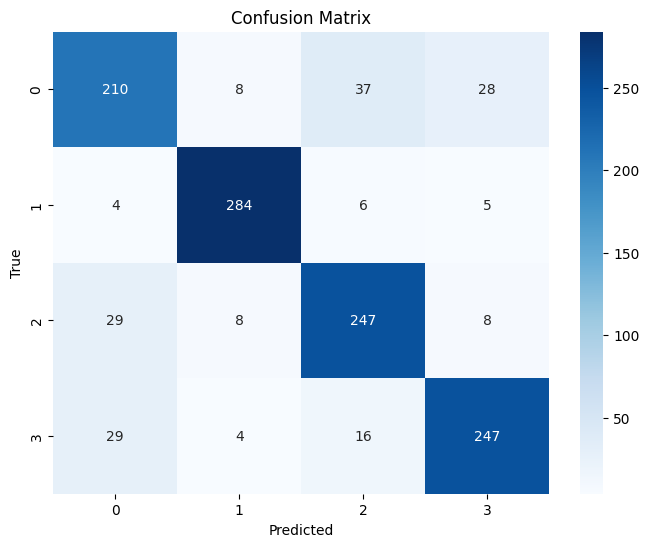

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 저장된 모델 로드
model = ViTForImageClassification.from_pretrained("/workspace/kms/models/vit-8444")
model.to(device)
model.eval()

# 예측 및 실제 값 저장
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        inputs = batch['pixel_values'].to(device)  # GPU로 이동
        labels = batch['label'].to(device)  # GPU로 이동

        outputs = model(inputs)
        _, preds = torch.max(outputs.logits, dim=1)  # 가장 높은 확률의 클래스 선택

        all_preds.extend(preds.cpu().numpy())  # 예측값을 CPU로 이동
        all_labels.extend(labels.cpu().numpy())  # 실제값을 CPU로 이동

# 혼동 행렬 생성
cm = confusion_matrix(all_labels, all_preds)

# 클래스 이름 정의 (예: 0, 1, 2, 3)
class_names = [0, 1, 2, 3]

# 혼동 행렬 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
